In [2]:
import pandas as pd
import os
import warnings

In [3]:
caminho = r"G:/Drives compartilhados/Qualidade/NOTIFICAÇÕES E ANÁLISE DE EVENTOS/NOTIFICAÇÕES 2026/02 - Fevereiro"
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

In [4]:
dfs = []

for arquivo in os.listdir(caminho):
    
    if arquivo.startswith("~$"):
        continue
    
    if arquivo.endswith((".xlsx", ".xls")):
        
        caminho_arquivo = os.path.join(caminho, arquivo)
        
        df = pd.read_excel(caminho_arquivo)
        
        # 🔥 PADRONIZAÇÃO
        df.columns = df.columns.str.strip()
        df.columns = df.columns.str.lower()
        
        dfs.append(df)

df_final = pd.concat(dfs, ignore_index=True)

In [5]:
df_final = df_final.dropna(how="all")
df_final = df_final.dropna(axis=1, how="all")

print(df_final.shape)

(260, 22)


In [6]:
display(df_final)

,data que o evento ocorreu,hospital onde o evento ocorreu,turno que o evento ocorreu,(setor notificado),setor onde o evento ocorreu (setor notificado),seu setor (setor notificante),qual incidente ocorreu,qual o grau do dano deste incidente,o incidente está relacionado a algum paciente ?,iniciais do nome,...,número do documento,gênero,titulo do incidente,descrição do incidente,ação corretiva imediata,fator contribuinte - o que pode ter causado o incidente (na sua opinião),fator atenuante - o que poderia ter evitado o incidente (na sua opinião)?,validação qualidade,data do envio,unnamed: 72
0,30/01/2026,Itaim,Diurno,Unidade de internação,Unidade de internação,ANESTESIOLOGIA,Ausência/falha no preenchimento dos documentos,Circunstância notificável,Sim,AAAM,...,52230680.0,Masculino,Falta documento de avaliação pré anestésica,Paciente com procedimento cirúrgico eletivo e ...,Comunicar Responsável,NaN,NaN,NaN,NaN,NaN
1,30/01/2026,Alphamed,Diurno,Centro Cirúrgico,Nutrição,ANESTESIOLOGIA,Atraso/falha na entrega de insumos pelo restau...,Circunstância notificável,Não,NaN,...,NaN,NaN,Qualidade Percebida,"Desde que a empresa de comida mudou, o café da...",Comunicar Responsável,NaN,NaN,NaN,NaN,NaN
2,30/01/2026,Vila Nova Star,Diurno,Setor de endoscopia,Setor de endoscopia,ANESTESIOLOGIA,Falha no agendamento cirúrgico/exames,Circunstância notificável,Sim,DTO,...,52238888.0,Masculino,Falha na orientação,"Paciente em uso de Rybelsus, última dose ontem...",Comunicar Responsável,NaN,NaN,NaN,NaN,NaN
3,30/01/2026,Morumbi,Diurno,Centro Cirúrgico,Centro Cirúrgico,ANESTESIOLOGIA,Atraso do procedimento cirúrgico,Circunstância notificável,Não,NaN,...,NaN,NaN,Atraso na cirúrgia,Atraso prolongado de procedimento cirúrgico em...,Comunicar Responsável,NaN,NaN,NaN,NaN,NaN
4,31/01/2026,Morumbi,Diurno,Internação,Internação,ANESTESIOLOGIA,Abertura involuntária da ferida operatória (de...,Circunstância notificável,Não,NaN,...,NaN,NaN,Falha na identificação,etiquetas de outra paciente com mesmo nome (F...,Comunicar Responsável,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,26/02/2026,Vila_Nova_Star,Diurno,Centro Cirúrgico,Centro Cirúrgico,Anestesiologia,Lesão de Pele,Circunstância notificável,Sim,FGF,...,52791952,Masculino,Lesão por pressão em panturrilha após procedim...,Paciente submetido a Rinosseptoplastia - 06:30...,Comunicar Responsavel,NaN,NaN,NaN,NaN,NaN
776,27/02/2026,Vila_Nova_Star,Diurno,Centro Cirúrgico,Centro Cirúrgico,Anestesiologia,Falha relacionada a recursos organizacionais,Circunstância notificável,Não,XX,...,XX,XX,Quantidade insuficiente de computadores na tor...,Torre 2: Ausência de computadores suficientes ...,Comunicar Responsavel,NaN,NaN,NaN,NaN,NaN
777,28/02/2026,Vila_Nova_Star,Não sei informar / NA (Não se Aplica),Unidade de internação,UI - Unidade de Internação / Adulto,Anestesiologia,Falha relacionada a recursos organizacionais,Circunstância notificável,Não,XX,...,XX,XX,Dificuldade de acesso à enfermaria da pediatri...,Notifico a dificuldade de conseguir entrar na ...,Comunicar Responsavel,NaN,NaN,NaN,NaN,NaN
778,28/02/2026,Vila_Nova_Star,Não sei informar / NA (Não se Aplica),Unidade de internação,UI - Unidade de Internação / Adulto,Anestesiologia,Falha relacionada a recursos organizacionais,Circunstância notificável,Não,XX,...,XX,XX,Dificuldade de acesso à enfermaria da pediatri...,Notifico a dificuldade de conseguir entrar na ...,Comunicar Responsavel,NaN,NaN,NaN,NaN,NaN


In [7]:
import pandas as pd
import re
from collections import Counter

# Escolha a coluna correta
coluna = "titulo do incidente"  # ajuste se necessário

# Junta tudo
texto = " ".join(df_final[coluna].dropna().astype(str))

# Limpeza
texto = texto.lower()
texto = re.sub(r"[^\w\s]", "", texto)

# Quebra em palavras
palavras = texto.split()

# Stopwords básicas (adicione mais depois se quiser)
stopwords = {
    "de","da","do","das","dos","e","em","para","com","sem","um","uma",
    "na","no","nas","nos","ao","aos","as","os","que","por","foi","não","nao", "apa", "alta"
}

# Remove palavras irrelevantes
palavras_filtradas = [p for p in palavras if p not in stopwords and len(p) > 2]

# Conta frequência
contagem = Counter(palavras_filtradas)

# Top 20
top_20 = contagem.most_common(20)

print(top_20)

[('falha', 122), ('falta', 60), ('manutenção', 29), ('atraso', 20), ('paciente', 17), ('termo', 15), ('insumos', 14), ('comportamental', 14), ('segura', 13), ('qualidade', 12), ('percebida', 12), ('materiais', 9), ('preventiva', 9), ('ruptura', 9), ('estoque', 9), ('anestésica', 8), ('aparelho', 8), ('preparo', 7), ('computador', 6), ('assistencia', 6)]


In [8]:
print(df_final.columns.tolist())

['data que o evento ocorreu', 'hospital onde o evento ocorreu', 'turno que o evento ocorreu', '(setor notificado)', 'setor onde o evento ocorreu (setor notificado)', 'seu setor (setor notificante)', 'qual incidente ocorreu', 'qual o grau do dano deste incidente', 'o incidente está relacionado a algum paciente ?', 'iniciais do nome', 'data de nascimento', 'tipo de documento', 'número do documento', 'gênero', 'titulo do incidente', 'descrição do incidente', 'ação corretiva imediata', 'fator contribuinte - o que pode ter causado o incidente (na sua opinião)', 'fator atenuante - o que poderia ter evitado o incidente (na sua opinião)?', 'validação qualidade', 'data do envio', 'unnamed: 72']


In [10]:
top_20 = [('falha', 122), ('falta', 60), ('manutenção', 29), ('atraso', 20), ('paciente', 17), ('termo', 15), ('insumos', 14), ('comportamental', 14), ('segura', 13), ('qualidade', 12), ('percebida', 12), ('materiais', 9), ('preventiva', 9), ('ruptura', 9), ('estoque', 9), ('anestésica', 8), ('aparelho', 8), ('preparo', 7), ('computador', 6), ('assistencia', 6)]

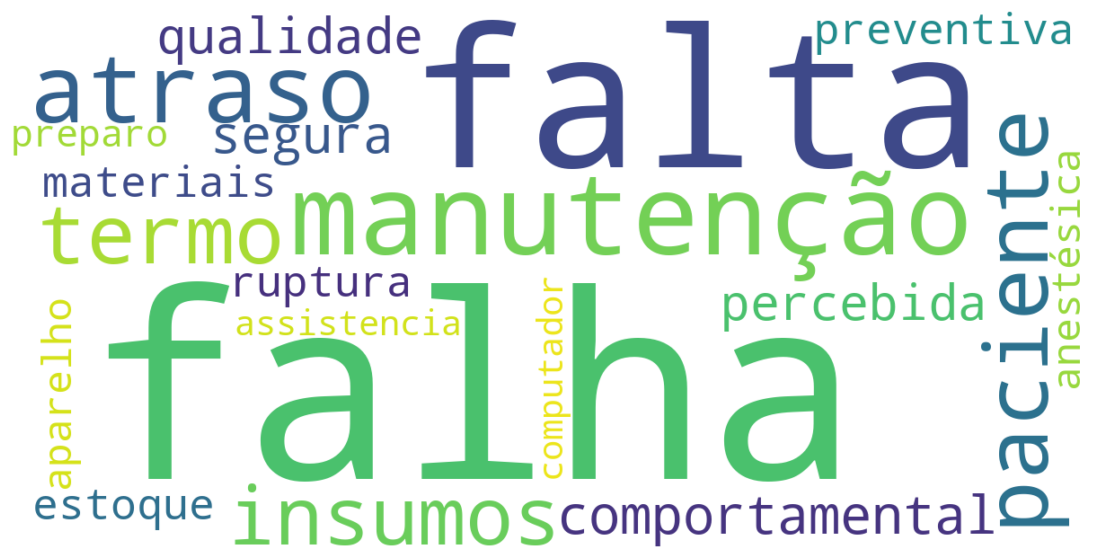

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Seu top 20
top_20 = [('falha', 122), ('falta', 60), ('manutenção', 29), ('atraso', 20),
          ('paciente', 17), ('termo', 15),
          ('insumos', 14), ('comportamental', 14), ('segura', 13),
          ('qualidade', 12), ('percebida', 12), ('materiais', 9),
          ('preventiva', 9), ('ruptura', 9), ('estoque', 9),
          ('anestésica', 8), ('aparelho', 8), ('preparo', 7), ('computador', 6), ('assistencia', 6)]

# Converter para dicionário
frequencias = dict(top_20)

# Criar nuvem
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(frequencias)

# Plotar
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
remover = {"paciente", "termo", "alta", "qualidade", "segura", "percebida", "apa"}

frequencias_filtradas = {
    k: v for k, v in frequencias.items() if k not in remover
}

In [ ]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Reds"  # ou "viridis", "coolwarm"
)